In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.qaoa_utils import QAOASolver

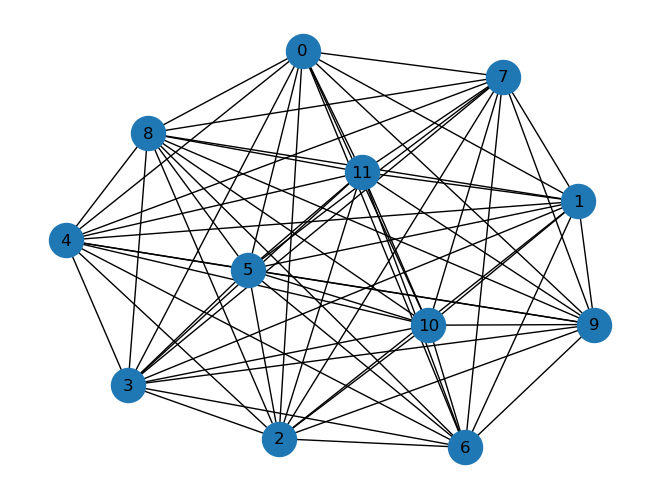

In [2]:
n = 12
k=3
# G = generate_k_regular_graph(num_vertices=n, k=k, weighted=True,seed=True)
G=generate_random_complete_graph(num_vertices=n, weighted=True, seed=True)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
# Optimal Maxcut Calculation 
optimal_max_cut_val = compute_optimal_max_cut(G)
print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

Optimal Max Cut Value : 239


In [4]:
max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIZZ', 'IIIIIIIIIZIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIIZ', 'IIIIIIZIIIIZ', 'IIIIIZIIIIIZ', 'IIIIZIIIIIIZ', 'IIIZIIIIIIIZ', 'IIZIIIIIIIIZ', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIIZ', 'IIIIIIIIIZZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IIIIZIIIIIZI', 'IIIZIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IIIIZIIIIZII', 'IIIZIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IIIIZIIIZIII', 'IIIZIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IIIIZIIZIIII', 'IIIZIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIIZZIIIII', 'IIIIZIZIIIII', 'IIIZIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZIIIII', 'ZIIIIIZIIIII', 'IIIIZZIIIIII', 'IIIZIZIIIIII', 'IIZIIZIIIIII', 'IZIIIZIIIIII', 'ZIIIIZIIIIII', 'IIIZZIIIIIII', 'IIZIZIIIIIII', 'IZIIZIIIIIII', 'ZIIIZIIIIIII'

In [5]:
reps = 2

#ma QAOA circuit
circuit = multi_angle_qaoa_circuit(n,G ,reps)

#vanilla QAOA circuit 
# circuit = QAOAAnsatz(cost_operator=cost_hamiltonian,reps=reps)

In [6]:
maxcut_qaoa = QAOASolver(cost_hamiltonian,circuit)
maxcut_qaoa.prepare_circuit()

In [7]:
circuit.parameters

ParameterView([Parameter(beta_0_0), Parameter(beta_0_1), Parameter(beta_10_0), Parameter(beta_10_1), Parameter(beta_11_0), Parameter(beta_11_1), Parameter(beta_1_0), Parameter(beta_1_1), Parameter(beta_2_0), Parameter(beta_2_1), Parameter(beta_3_0), Parameter(beta_3_1), Parameter(beta_4_0), Parameter(beta_4_1), Parameter(beta_5_0), Parameter(beta_5_1), Parameter(beta_6_0), Parameter(beta_6_1), Parameter(beta_7_0), Parameter(beta_7_1), Parameter(beta_8_0), Parameter(beta_8_1), Parameter(beta_9_0), Parameter(beta_9_1), Parameter(gamma_0_10_0), Parameter(gamma_0_10_1), Parameter(gamma_0_11_0), Parameter(gamma_0_11_1), Parameter(gamma_0_1_0), Parameter(gamma_0_1_1), Parameter(gamma_0_2_0), Parameter(gamma_0_2_1), Parameter(gamma_0_3_0), Parameter(gamma_0_3_1), Parameter(gamma_0_4_0), Parameter(gamma_0_4_1), Parameter(gamma_0_5_0), Parameter(gamma_0_5_1), Parameter(gamma_0_6_0), Parameter(gamma_0_6_1), Parameter(gamma_0_7_0), Parameter(gamma_0_7_1), Parameter(gamma_0_8_0), Parameter(gamma_0

In [8]:
maxcut_qaoa.param_map

{0: 0,
 1: 1,
 2: 10,
 3: 109,
 4: 111,
 5: 112,
 6: 113,
 7: 114,
 8: 115,
 9: 116,
 10: 117,
 11: 118,
 12: 119,
 13: 11,
 14: 120,
 15: 122,
 16: 123,
 17: 124,
 18: 125,
 19: 126,
 20: 127,
 21: 128,
 22: 129,
 23: 130,
 24: 12,
 25: 131,
 26: 133,
 27: 135,
 28: 137,
 29: 139,
 30: 141,
 31: 143,
 32: 145,
 33: 147,
 34: 149,
 35: 13,
 36: 151,
 37: 153,
 38: 14,
 39: 15,
 40: 16,
 41: 17,
 42: 18,
 43: 19,
 44: 2,
 45: 20,
 46: 21,
 47: 22,
 48: 23,
 49: 24,
 50: 25,
 51: 26,
 52: 27,
 53: 28,
 54: 29,
 55: 3,
 56: 30,
 57: 31,
 58: 32,
 59: 33,
 60: 34,
 61: 35,
 62: 36,
 63: 37,
 64: 38,
 65: 39,
 66: 4,
 67: 40,
 68: 41,
 69: 42,
 70: 43,
 71: 44,
 72: 45,
 73: 46,
 74: 47,
 75: 48,
 76: 49,
 77: 5,
 78: 50,
 79: 51,
 80: 52,
 81: 53,
 82: 54,
 83: 55,
 84: 57,
 85: 59,
 86: 60,
 87: 62,
 88: 6,
 89: 63,
 90: 64,
 91: 66,
 92: 67,
 93: 68,
 94: 69,
 95: 71,
 96: 72,
 97: 73,
 98: 74,
 99: 7,
 100: 75,
 101: 77,
 102: 78,
 103: 79,
 104: 80,
 105: 81,
 106: 82,
 107: 84,
 108: 

In [9]:
maxcut_qaoa.stim_circ.number_parametrized_gates()

156

In [10]:
#Run CAFQA process 
maxcut_qaoa.run_CAFQA(n_gens=10)

STARTING ROUND 0




started GA at id 1 with 1 procs

started GA at id 2 with 1 procs


started GA at id 3 with 1 procs
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=156
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=156
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=156
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_p

In [11]:
maxcut_qaoa.energy_best

np.float64(-10.0)

In [12]:
maxcut_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -93.99999999999993


np.float64(-93.99999999999993)

In [13]:
ordered_params = [param.name for param in maxcut_qaoa.pcirc.parameters]
angle_multipliers = [-np.pi/4 if 'gamma' in param else np.pi/4 for param in ordered_params]

random_params = np.random.random(len(ordered_params))
cafqa_params = [param * (np.pi/2) for param,multiplier in zip(maxcut_qaoa.ks_best,angle_multipliers)] #This has to be in the order we come across the gates.

In [22]:
maxcut_qaoa.evaluate_energy(maxcut_qaoa.pcirc,cost_hamiltonian,cafqa_params,noise=True,err=1e-3)

array(-7.0390625)

In [30]:
cafqa_result, cafqa_obj_values =maxcut_qaoa.run_qaoa(cafqa_params,max_iters=10)
random_result, random_obj_values =maxcut_qaoa.run_qaoa(random_params,max_iters=10)

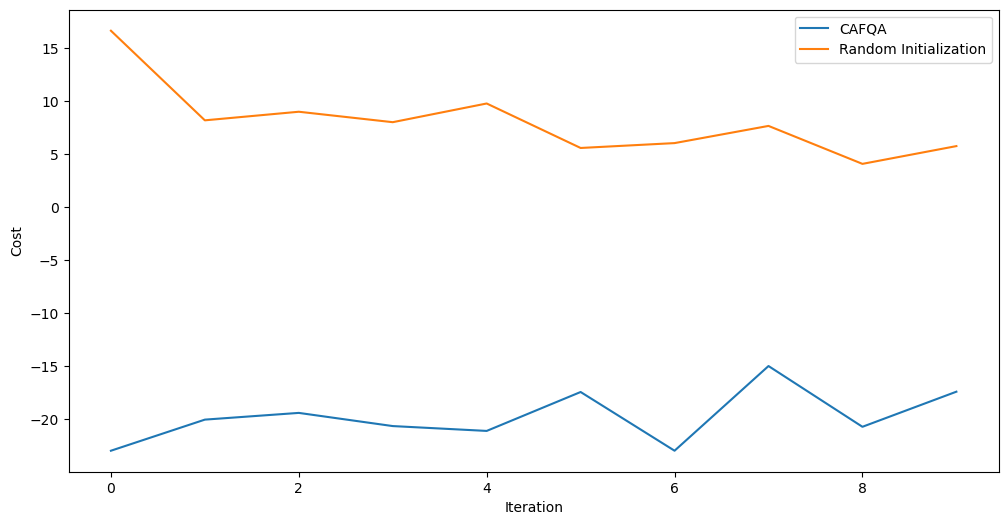

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_obj_values, label="CAFQA")
plt.plot(random_obj_values, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

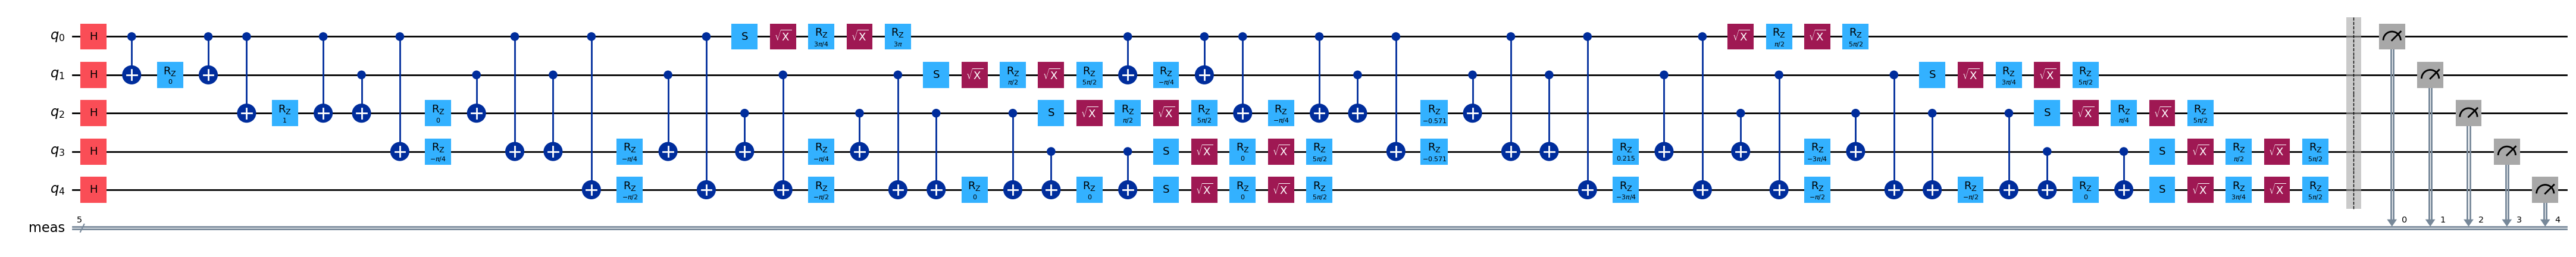

In [18]:
optimized_circuit = maxcut_qaoa.pcirc.assign_parameters(cafqa_result.x)
optimized_circuit.measure_all()
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [19]:
sampler = Sampler(mode=maxcut_qaoa.backend)
sampler.options.default_shots = 10000

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

{3: 0.0811, 22: 0.0458, 1: 0.0195, 14: 0.0354, 20: 0.0731, 9: 0.0447, 16: 0.0256, 0: 0.0096, 19: 0.0505, 13: 0.0202, 18: 0.0226, 21: 0.0141, 10: 0.014, 17: 0.0368, 23: 0.0098, 24: 0.0365, 6: 0.0199, 12: 0.0436, 15: 0.025, 28: 0.0823, 4: 0.0323, 7: 0.0401, 11: 0.07, 27: 0.0351, 5: 0.0197, 26: 0.0178, 31: 0.0089, 30: 0.0219, 2: 0.0073, 25: 0.0211, 8: 0.0085, 29: 0.0072}


In [15]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(G))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 0, 1, 1, 0, 0, 0, 0, 0]


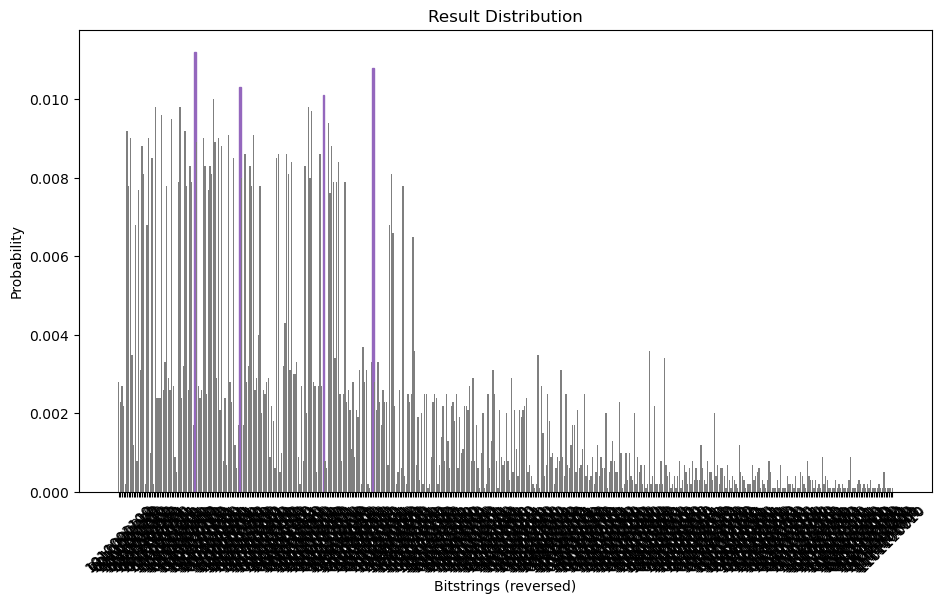

In [16]:
matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0][0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

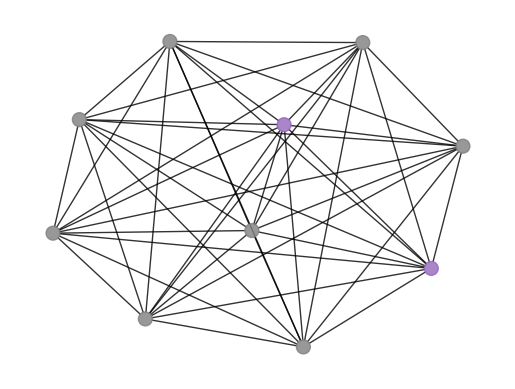

In [17]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(G, most_likely_bitstring)

In [18]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(w*(x[u] * (1 - x[v]) + x[v] * (1 - x[u])) for u, v,w in list(graph.weighted_edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, G)
print('The value of the cut is:', cut_value)

The value of the cut is: 102


In [19]:
top_4_values

[np.float64(0.0112),
 np.float64(0.0108),
 np.float64(0.0103),
 np.float64(0.0101)]